# Project Cycle 2: Confidence Intervals and One-Sample Inference
**Team Name:** [第七組]
**Team Members:** [楊書雅、黃睿恩、黃柏維]

## 1. Introduction & Research Questions
本專案旨在利用 YRBS 2007 資料集進行單一樣本推論。我們挑選了以下兩個變數進行分析：
1. **比例分析 (類別變數)**：`EverCigaretteUse` (是否曾吸菸)。
   * **基準值**：$p_0 = 0.50$
   * **研究問題**：美國高中生曾吸菸的母體比例，是否顯著不等於 0.50？
2. **平均數分析 (連續變數)**：`BMIPCT` (BMI 百分位數)。
   * **基準值**：$\mu_0 = 65.0$
   * **研究問題**：美國高中生的 BMI 百分位數母體平均值，是否顯著不等於 65.0？


## 1. Setup & Data Loading

In [8]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

# 設定繪圖風格
sns.set_theme(style="whitegrid")

# 讀取原始資料
df = pd.read_csv('YRBS_2007.csv')
print(f"Dataset shape: {df.shape}")

Dataset shape: (14041, 103)


## 2. Data Check & Recoding
在進行分析前，我們需要清理資料並將變數重新編碼。
* 對於 `EverCigaretteUse`：我們排除遺失值，並將代碼 `1` (Yes) 重新編碼為成功 (`1`)，代碼 `2` (No) 重新編碼為失敗 (`0`)。
* 對於 `BMIPCT`：我們僅排除遺失值 (NaN) 以保留有效樣本。

In [9]:
# 2. Data Check & Recoding

# 處理 EverCigaretteUse
df_cig = df.dropna(subset=['EverCigaretteUse']).copy()
df_cig = df_cig[df_cig['EverCigaretteUse'].isin([1, 2])]
df_cig['EverCigaretteUse_Binary'] = df_cig['EverCigaretteUse'].replace({1: 1, 2: 0})

# 處理 BMIPCT
df_bmi = df.dropna(subset=['BMIPCT']).copy()

print(f"Cleaned sample size for EverCigaretteUse: {len(df_cig)}")
print(f"Cleaned sample size for BMIPCT: {len(df_bmi)}")

Cleaned sample size for EverCigaretteUse: 13601
Cleaned sample size for BMIPCT: 13062


## 3. Exploratory Data Analysis (EDA)
### 3.1 Proportion Variable: EverCigaretteUse
首先，我們觀察曾吸菸學生的比例分佈。

--- Frequency Table (Binary) ---
EverCigaretteUse_Binary
1.0    0.526726
0.0    0.473274
Name: proportion, dtype: float64


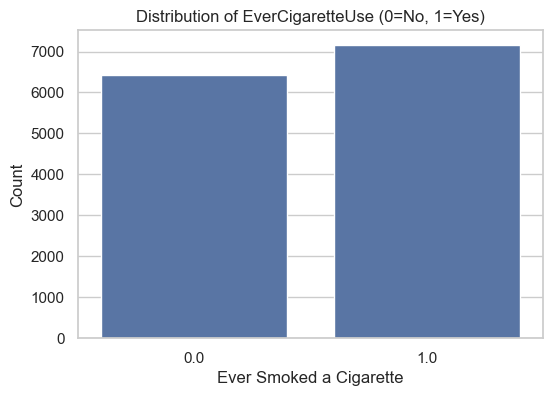

In [10]:
# 3.1 EDA: EverCigaretteUse
print("--- Frequency Table (Binary) ---")
print(df_cig['EverCigaretteUse_Binary'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(data=df_cig, x='EverCigaretteUse_Binary')
plt.title('Distribution of EverCigaretteUse (0=No, 1=Yes)')
plt.xlabel('Ever Smoked a Cigarette')
plt.ylabel('Count')
plt.show()

**EDA 觀察 (EverCigaretteUse)**：
> [請小組在這裡填寫觀察結果：例如，從長條圖與頻率表可以看出，回答 No (0) 的人數與回答 Yes (1) 的人數大約各佔多少比例？這與我們的基準值 0.50 接近嗎？]

### 3.2 Continuous Variable: BMIPCT
接著，我們檢視 BMI 百分位數的分佈與集中趨勢。

--- Summary Statistics for BMIPCT ---
count    1.306200e+04
mean     6.482068e+01
std      2.751676e+01
min      3.720000e-09
25%      4.516627e+01
50%      7.013853e+01
75%      8.945097e+01
max      9.993921e+01
Name: BMIPCT, dtype: float64


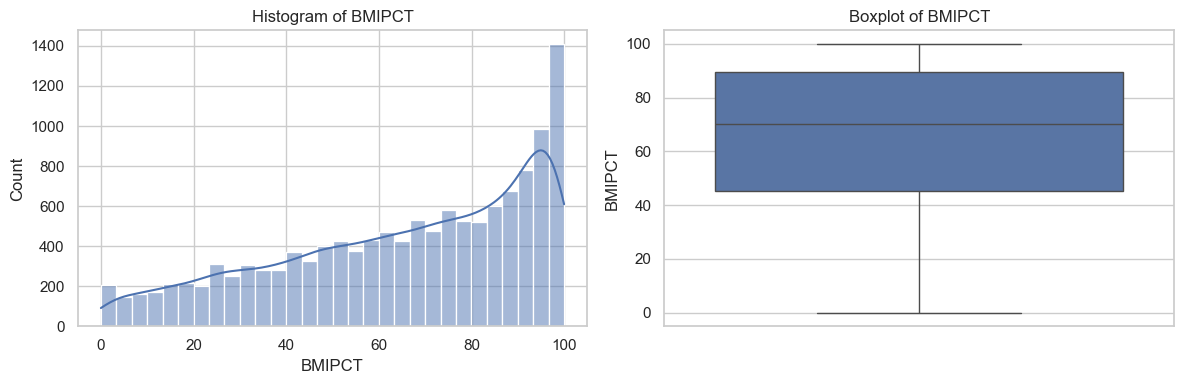

In [11]:
# 3.2 EDA: BMIPCT
print("--- Summary Statistics for BMIPCT ---")
print(df_bmi['BMIPCT'].describe())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df_bmi['BMIPCT'], bins=30, kde=True, ax=ax[0])
ax[0].set_title('Histogram of BMIPCT')

sns.boxplot(y=df_bmi['BMIPCT'], ax=ax[1])
ax[1].set_title('Boxplot of BMIPCT')

plt.tight_layout()
plt.show()

**EDA 觀察 (BMIPCT)**：
> [請小組在這裡填寫觀察結果：例如，平均數與中位數大約落在哪裡？直方圖呈現什麼形狀（偏態或對稱）？箱型圖有顯示極端的離群值嗎？平均數看起來大於還是小於基準值 65.0？]

### 3.3 Custom EDA: BMIPCT by Cigarette Use
(專案要求至少一項額外的 EDA 探索)

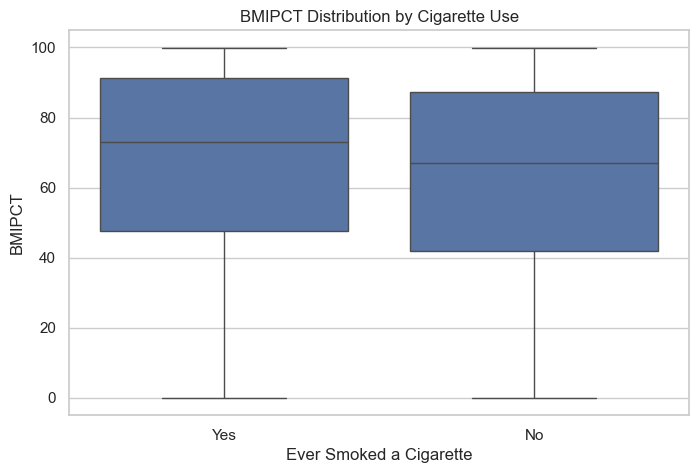

In [13]:
# 3.3 Custom EDA (結合兩個變數做分組比較)
# 找出同時擁有這兩個變數資料的學生
df_combined = df.dropna(subset=['EverCigaretteUse', 'BMIPCT']).copy()
df_combined['EverCigaretteUse_Binary'] = df_combined['EverCigaretteUse'].replace({1: 'Yes', 2: 'No'})

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_combined, x='EverCigaretteUse_Binary', y='BMIPCT')
plt.title('BMIPCT Distribution by Cigarette Use')
plt.xlabel('Ever Smoked a Cigarette')
plt.ylabel('BMIPCT')
plt.show()

**EDA 觀察 (Custom)**：
> [請小組在這裡填寫觀察結果：曾吸菸與未曾吸菸的學生，他們的 BMI 百分位數分佈看起來有明顯差異嗎？]

---
## 4. Statistical Inference
### 4.1 Inference for Population Proportion (EverCigaretteUse)
* **Null Hypothesis ($H_0$)**: $p = 0.50$
* **Alternative Hypothesis ($H_A$)**: $p \neq 0.50$
* **Alpha level ($\alpha$)**: 0.05

In [16]:
# 4.1 Inference: EverCigaretteUse
p_0 = 0.50
successes = df_cig['EverCigaretteUse_Binary'].sum()
n_trials = len(df_cig)

# 計算 95% 信賴區間
ci_low, ci_high = proportion_confint(count=successes, nobs=n_trials, alpha=0.05, method='normal')

# Z-test
stat_z, p_val_z = proportions_ztest(count=successes, nobs=n_trials, value=p_0)

print(f"Sample Proportion: {successes/n_trials:.4f}")
print(f"95% Confidence Interval: ({ci_low:.4f}, {ci_high:.4f})")
print(f"Z-statistic: {stat_z:.4f}, p-value: {p_val_z:.4e}")

Sample Proportion: 0.5267
95% Confidence Interval: (0.5183, 0.5351)
Z-statistic: 6.2427, p-value: 4.3017e-10


**推論詮釋 (EverCigaretteUse)**：
> [請小組填寫：信賴區間包含 0.50 嗎？p-value 是否小於 0.05？因此我們決定（拒絕 / 不拒絕）虛無假設。這代表我們（有 / 沒有）足夠證據宣稱高中生曾吸菸的母體比例不等於 0.50。]

### 4.2 Inference for Population Mean (BMIPCT)
* **Null Hypothesis ($H_0$)**: $\mu = 65.0$
* **Alternative Hypothesis ($H_A$)**: $\mu \neq 65.0$
* **Alpha level ($\alpha$)**: 0.05

In [18]:
# 4.2 Inference: BMIPCT
mu_0 = 65.0
sample_mean = df_bmi['BMIPCT'].mean()
sample_std = df_bmi['BMIPCT'].std(ddof=1)
n_bmi = len(df_bmi)

# 計算 95% 信賴區間
ci_mean_low, ci_mean_high = stats.t.interval(confidence=0.95, df=n_bmi-1, loc=sample_mean, scale=sample_std/np.sqrt(n_bmi))

# T-test
t_stat, p_val_t = stats.ttest_1samp(a=df_bmi['BMIPCT'], popmean=mu_0)

print(f"Sample Mean: {sample_mean:.4f}")
print(f"95% Confidence Interval: ({ci_mean_low:.4f}, {ci_mean_high:.4f})")
print(f"T-statistic: {t_stat:.4f}, p-value: {p_val_t:.4e}")

Sample Mean: 64.8207
95% Confidence Interval: (64.3487, 65.2926)
T-statistic: -0.7448, p-value: 4.5642e-01


**推論詮釋 (BMIPCT)**：
> [信賴區間包含 65.0 嗎？p-value 的結果為何？這代表我們是否有足夠證據拒絕虛無假設？這個推論結果與我們在 EDA 中觀察到的平均數吻合嗎？]

---
## 5. Conclusion
> [結合上述的 EDA 圖表與推論結果，給出一個對非統計背景的人也能看懂的結論。]